# Build a Neural Network from Scratch using NumPy

Implementing a neural network from scratch is one of the best ways to understand how deep learning works internally. Instead of using frameworks like TensorFlow or PyTorch, we'll use only NumPy to implement all the mathematics ourselves.

## Step 1: Import NumPy

In [1]:
import numpy as np

## Step 2: Create Dataset

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

## Step 3: Initialize Parameters

In [3]:
np.random.seed(42)

W1 = np.random.randn(2,4)
b1 = np.zeros((1,4))

W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))

## Step 4: Activation Functions

**Relu:**

In [4]:
def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return (x>0).astype(float)

**Sigmoid:**

In [6]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s*(1-s)

## Step 5: Forward Propagation

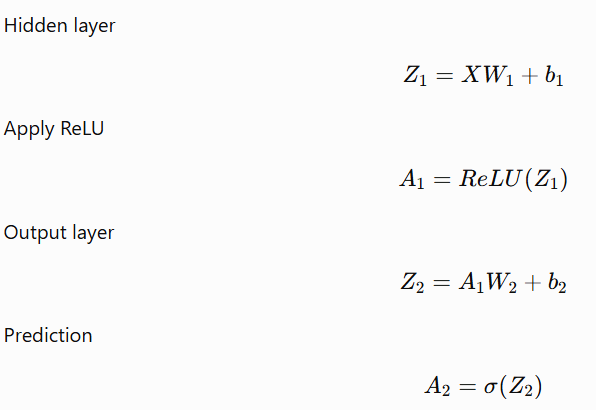

In [7]:
Z1 = np.dot(X,W1) + b1 # Hidden layer
A1 = relu(Z1) # Activation Function

Z2 = np.dot(A1,W2) + b2 # Output Layer
A2 = sigmoid(Z2) # Prediction

## Step 6: Compute Loss

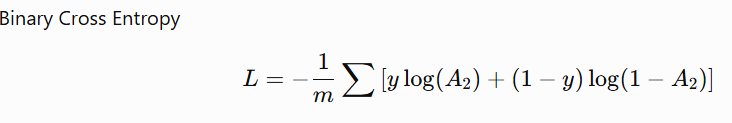

In [8]:
m = y.shape[0]

loss = -np.mean(
    y*np.log(A2+1e-8) +
    (1-y)*np.log(1-A2+1e-8)
)

Small value "1e-8" prevents log(0)

## Step 7: Backpropagation

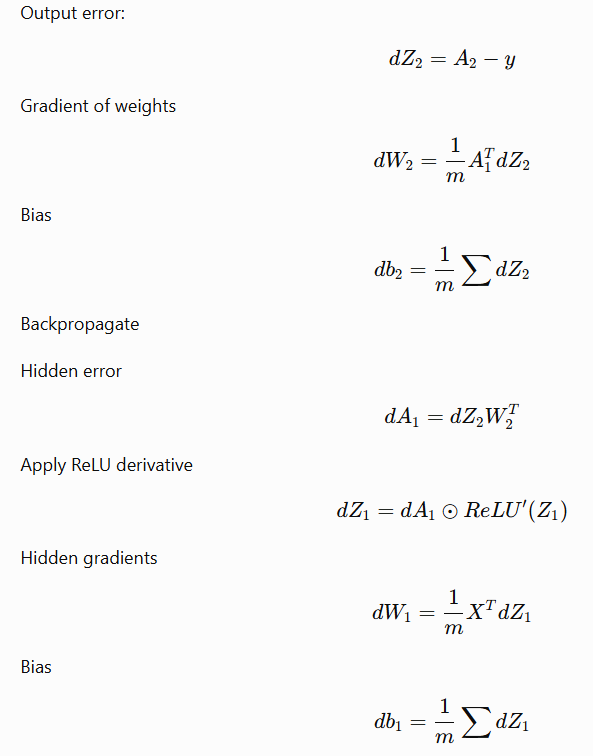

In [9]:
m = X.shape[0]

dZ2 = A2 - y
dW2 = (1/m) * np.dot(A1.T,dZ2)
db2 = (1/m) * np.sum(dZ2,axis=0,keepdims=True)

dA1 = np.dot(dZ2,W2.T)
dZ1 = dA1 * relu_derivative(Z1)

dW1 = (1/m) * np.dot(X.T,dZ1)
db1 = (1/m) * np.sum(dZ1,axis=0,keepdims=True)

## Step 8: Gradient Descent

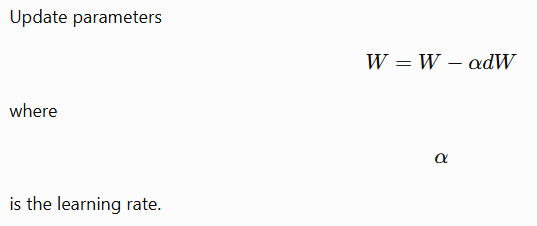

In [10]:
learning_rate = 0.1

W1 -= learning_rate*dW1
b1 -= learning_rate*db1

W2 -= learning_rate*dW2
b2 -= learning_rate*db2

## Step 9: Training Loop

**Repeat:**

- Forward propagation
- Compute loss
- Backpropagation
- Update weights




In [11]:

for epoch in range(10000):

    # Forward
    Z1 = np.dot(X,W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2) + b2
    A2 = sigmoid(Z2)

    # Loss
    loss = -np.mean(
        y*np.log(A2+1e-8) +
        (1-y)*np.log(1-A2+1e-8)
    )

    # Backward
    m = X.shape[0]

    dZ2 = A2-y
    dW2 = (1/m)*np.dot(A1.T,dZ2)
    db2 = (1/m)*np.sum(dZ2,axis=0,keepdims=True)

    dA1 = np.dot(dZ2,W2.T)
    dZ1 = dA1*relu_derivative(Z1)

    dW1 = (1/m)*np.dot(X.T,dZ1)
    db1 = (1/m)*np.sum(dZ1,axis=0,keepdims=True)

    # Update
    W1 -= learning_rate*dW1
    b1 -= learning_rate*db1

    W2 -= learning_rate*dW2
    b2 -= learning_rate*db2

    if epoch % 1000 == 0:
        print(epoch, loss)

0 0.8765828223048977
1000 0.0684917532552239
2000 0.018270010890431693
3000 0.009823977210971042
4000 0.006578205286011449
5000 0.004897652099312015
6000 0.003882816678103172
7000 0.003204533721484852
8000 0.0027226832101483345
9000 0.0023624601706311453


## Step 10: Prediction

In [12]:
Z1 = np.dot(X,W1)+b1
A1 = relu(Z1)

Z2 = np.dot(A1,W2)+b2
predictions = sigmoid(Z2)

print(predictions)

[[5.78103963e-03]
 [9.99059829e-01]
 [9.99059909e-01]
 [6.56625931e-04]]


Convert probabilities to binary labels:

In [13]:
predicted_labels = (predictions >= 0.5).astype(int)
print(predicted_labels)

[[0]
 [1]
 [1]
 [0]]


### Key Takeaways
- A neural network is built by stacking layers of linear transformations and nonlinear activation functions.
- **Forward propagation** computes predictions from the input.
- **A loss function** measures the prediction error.
- **Backpropagation** computes gradients of the loss with respect to every parameter using the chain rule.
- **Gradient descent** updates the weights and biases to minimize the loss.
- Repeating this cycle over many epochs allows the network to learn patterns from the data.
- Libraries such as TensorFlow and PyTorch automate these operations, but implementing them with NumPy provides a clear understanding of the underlying mathematics and training process.


